In [1]:
%%writefile criba_cuda_validation.cu
#include <iostream>
#include <vector>
#include <cmath>
#include <chrono>
#include <iomanip>
#include <cuda_runtime.h>

// Estructura Compacta de 16 bytes para la base de generadores
struct alignas(16) PrimoGenerador {
    uint32_t p;
    uint32_t k_p;
    uint32_t kmin_plus;
    uint32_t kmin_minus;
    bool es_c5;
};

// ==========================================
// FUNCIONES HOST (Fase 1 Secuencial)
// ==========================================
bool es_primo_estricto(uint64_t k, bool check_c5, const std::vector<PrimoGenerador>& base) {
    if (k > 3) {
        uint64_t ultimo_digito = k % 10;
        if (check_c5 && (ultimo_digito == 1 || ultimo_digito == 6)) return false;
        if (!check_c5 && (ultimo_digito == 4 || ultimo_digito == 9)) return false;
    }
    uint64_t n_cand = check_c5 ? (6 * k - 1) : (6 * k + 1);
    for (const auto& gen : base) {
        if (gen.p > n_cand / gen.p) break;
        if (check_c5 == gen.es_c5) {
            if ((k - gen.k_p) % gen.p == 0) return false;
        } else {
            if ((k + gen.k_p) % gen.p == 0) return false;
        }
    }
    return true;
}

uint64_t encontrar_nextkop(uint64_t k_inicio, bool c5_objetivo, const std::vector<PrimoGenerador>& base) {
    uint64_t k = k_inicio;
    while (true) {
        if (es_primo_estricto(k, c5_objetivo, base)) return k;
        k++;
    }
}

// ==========================================
// KERNEL CUDA (Con Contadores por Canal)
// ==========================================
__global__ void criba_kernel_validation(uint64_t k_inicio, uint64_t k_max, const PrimoGenerador* __restrict__ d_base, int base_size, unsigned long long* d_c5, unsigned long long* d_c1) {
    uint64_t idx = blockIdx.x * blockDim.x + threadIdx.x;
    uint64_t k = k_inicio + idx;

    if (k > k_max) return;

    // Canal C5 (6k - 1)
    bool es_primo_c5 = true;
    if (k > 3 && (k % 10 == 1 || k % 10 == 6)) {
        es_primo_c5 = false;
    } else {
        for (int i = 0; i < base_size; ++i) {
            PrimoGenerador gen = d_base[i];
            if (k < gen.kmin_minus) break;
            if (gen.es_c5) {
                if ((k - gen.k_p) % gen.p == 0) { es_primo_c5 = false; break; }
            } else {
                if ((k + gen.k_p) % gen.p == 0) { es_primo_c5 = false; break; }
            }
        }
    }
    if (es_primo_c5) atomicAdd(d_c5, 1ULL);

    // Canal C1 (6k + 1)
    bool es_primo_c1 = true;
    if (k > 3 && (k % 10 == 4 || k % 10 == 9)) {
        es_primo_c1 = false;
    } else {
        for (int i = 0; i < base_size; ++i) {
            PrimoGenerador gen = d_base[i];
            if (k < gen.kmin_plus) break;
            if (!gen.es_c5) {
                if ((k - gen.k_p) % gen.p == 0) { es_primo_c1 = false; break; }
            } else {
                if ((k + gen.k_p) % gen.p == 0) { es_primo_c1 = false; break; }
            }
        }
    }
    if (es_primo_c1) atomicAdd(d_c1, 1ULL);
}

// ==========================================
// EJECUTOR DE UN PUNTO DE VALIDACIÓN
// ==========================================
void evaluar_escala(uint64_t k_max) {
    uint64_t n_max = 6 * k_max + 1;
    uint64_t limite_base = static_cast<uint64_t>(std::sqrt(n_max));
    uint64_t k_lim_base = (limite_base / 6) + 1;

    uint64_t c5_host = 1; // Primo 5 (6k-1 con k=1)
    uint64_t c1_host = 1; // Primo 7 (6k+1 con k=1)

    std::vector<PrimoGenerador> base;
    base.reserve(4000);

    auto start_time = std::chrono::high_resolution_clock::now();

    // 1. POBLAR BASE (Fase 1 CPU)
    for (uint64_t k = 1; k <= k_lim_base; ++k) {
        bool es_primo_c5 = true;
        if (k > 3 && (k % 10 == 1 || k % 10 == 6)) { es_primo_c5 = false; }
        else {
            for (const auto& gen : base) {
                if (k < gen.kmin_minus) break;
                if (gen.es_c5) { if ((k - gen.k_p) % gen.p == 0) { es_primo_c5 = false; break; } }
                else           { if ((k + gen.k_p) % gen.p == 0) { es_primo_c5 = false; break; } }
            }
        }
        if (es_primo_c5) {
            uint64_t p_real = 6 * k - 1;
            if (k > 1) c5_host++;
            if (p_real <= limite_base) {
                uint64_t k_q = encontrar_nextkop(k, false, base);
                base.push_back({static_cast<uint32_t>(p_real), static_cast<uint32_t>(k),
                                static_cast<uint32_t>(p_real * k - k), static_cast<uint32_t>(p_real * k_q + k), true});
            }
        }

        bool es_primo_c1 = true;
        if (k > 3 && (k % 10 == 4 || k % 10 == 9)) { es_primo_c1 = false; }
        else {
            for (const auto& gen : base) {
                if (k < gen.kmin_plus) break;
                if (!gen.es_c5) { if ((k - gen.k_p) % gen.p == 0) { es_primo_c1 = false; break; } }
                else            { if ((k + gen.k_p) % gen.p == 0) { es_primo_c1 = false; break; } }
            }
        }
        if (es_primo_c1) {
            uint64_t p_real = 6 * k + 1;
            if (k > 1) c1_host++;
            if (p_real <= limite_base) {
                uint64_t k_q = encontrar_nextkop(k, true, base);
                base.push_back({static_cast<uint32_t>(p_real), static_cast<uint32_t>(k),
                                static_cast<uint32_t>(p_real * k + k), static_cast<uint32_t>(p_real * k_q - k), false});
            }
        }
    }

    // 2. PARALELIZACIÓN EN GPU (Fase 2)
    int base_size = base.size();
    PrimoGenerador* d_base;
    unsigned long long *d_c5, *d_c1;

    cudaMalloc(&d_base, base_size * sizeof(PrimoGenerador));
    cudaMemcpy(d_base, base.data(), base_size * sizeof(PrimoGenerador), cudaMemcpyHostToDevice);

    cudaMalloc(&d_c5, sizeof(unsigned long long));
    cudaMalloc(&d_c1, sizeof(unsigned long long));
    cudaMemset(d_c5, 0, sizeof(unsigned long long));
    cudaMemset(d_c1, 0, sizeof(unsigned long long));

    uint64_t k_elementos = k_max - k_lim_base;
    int blockSize = 256;
    int numBlocks = (k_elementos + blockSize - 1) / blockSize;

    if (k_elementos > 0) {
        criba_kernel_validation<<<numBlocks, blockSize>>>(k_lim_base + 1, k_max, d_base, base_size, d_c5, d_c1);
        cudaDeviceSynchronize();
    }

    unsigned long long c5_gpu, c1_gpu;
    cudaMemcpy(&c5_gpu, d_c5, sizeof(unsigned long long), cudaMemcpyDeviceToHost);
    cudaMemcpy(&c1_gpu, d_c1, sizeof(unsigned long long), cudaMemcpyDeviceToHost);

    auto end_time = std::chrono::high_resolution_clock::now();
    std::chrono::duration<double> elapsed = end_time - start_time;

    // Conteo total incluyendo los primos axiómicos 2 y 3
    uint64_t total_c5 = c5_host + c5_gpu;
    uint64_t total_c1 = c1_host + c1_gpu;
    uint64_t total_primos = 2 + total_c5 + total_c1;

    double memoria_kb = (base_size * 16.0) / 1024.0;
    double pi_teorico = n_max / std::log(n_max);
    double desviacion_pnt = ((total_primos - pi_teorico) / pi_teorico) * 100.0;
    double ratio_q = static_cast<double>(total_c1) / total_c5;

    std::cout << std::setw(11) << k_max << " | "
              << std::setw(11) << n_max << " | "
              << std::setw(10) << total_primos << " | "
              << std::setw(11) << std::fixed << std::setprecision(2) << desviacion_pnt << " | "
              << std::setw(9) << std::setprecision(3) << elapsed.count() << " | "
              << std::setw(9) << std::setprecision(1) << memoria_kb << " | "
              << std::setw(6) << base_size << " | "
              << std::setw(7) << std::setprecision(4) << ratio_q << "\n";

    cudaFree(d_base);
    cudaFree(d_c5);
    cudaFree(d_c1);
}

int main() {
    std::vector<uint64_t> escalas_prueba = {
        1000, 10000, 50000, 100000, 500000,
        1000000, 5000000, 10000000, 50000000, 166666666,
        1666666666
    };

    std::cout << "============================================================================================================\n";
    std::cout << " INICIANDO VALIDACIÓN EMPÍRICA MULTI-ESCALA CUDA (Ref: Tablas 6.1 y 6.2 del Manuscrito)\n";
    std::cout << "============================================================================================================\n";
    std::cout << "      k_max |       N_max |     Primos | Desv PNT(%) | Tiempo(s) |   Mem(KB) |   Base | Ratio Q\n";
    std::cout << "------------------------------------------------------------------------------------------------------------\n";

    for (uint64_t k_max : escalas_prueba) {
        evaluar_escala(k_max);
    }

    std::cout << "------------------------------------------------------------------------------------------------------------\n";
    std::cout << "✅ Validación completada. Simetría quiral convergente a 1.000 y memoria acotada en O(√N).\n";

    return 0;
}

Writing criba_cuda_validation.cu


In [2]:
!nvcc -O3 -arch=sm_75 -use_fast_math criba_cuda_validation.cu -o criba_cuda_validation
!./criba_cuda_validation

 INICIANDO VALIDACIÓN EMPÍRICA MULTI-ESCALA CUDA (Ref: Tablas 6.1 y 6.2 del Manuscrito)
      k_max |       N_max |     Primos | Desv PNT(%) | Tiempo(s) |   Mem(KB) |   Base | Ratio Q
------------------------------------------------------------------------------------------------------------
       1000 |        6001 |        783 |       13.51 |     0.334 |       0.3 |     19 |  0.9673
      10000 |       60001 |       6057 |       11.06 |     0.000 |       0.8 |     51 |  0.9911
      50000 |      300001 |      25997 |        9.29 |     0.000 |       1.5 |     99 |  0.9958
     100000 |      600001 |      49098 |        8.87 |     0.001 |       2.1 |    135 |  0.9980
     500000 |     3000001 |     216816 |        7.79 |     0.003 |       4.2 |    267 |  0.9987
    1000000 |     6000001 |     412849 |        7.39 |     0.007 |       5.6 |    361 |  0.9992
    5000000 |    30000001 |    1857860 |        6.62 |     0.065 |      11.3 |    721 |  0.9996
   10000000 |    60000001 |    3562

In [4]:
import math
import subprocess

def ejecutar_y_analizar_cuda_stream():
    # 1. Iniciar el proceso CUDA streaming la salida en tiempo real
    proceso = subprocess.Popen(
        ['./criba_cuda_validation'],
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
        bufsize=1
    )

    resultados = {}

    # 2. Leer la salida estándar línea por línea conforme la GPU calcula
    for linea in iter(proceso.stdout.readline, ''):
        print(linea, end='') # Muestra la tabla en tiempo real
        partes = [p.strip() for p in linea.split('|')]
        if len(partes) == 8 and partes[0].isdigit():
            k_max = int(partes[0])
            tiempo = float(partes[4])
            memoria = float(partes[5])
            resultados[k_max] = {'tiempo': tiempo, 'memoria': memoria}

    proceso.stdout.close()
    proceso.wait()

    # 3. Generar la Tabla 6.3 de Análisis de Complejidad
    print("\n" + "=" * 90)
    print(" ANÁLISIS EMPÍRICO DE COMPLEJIDAD CUDA (Ref: Tabla 6.3 del Manuscrito)")
    print("=" * 90)
    print(f"{'Transición':>22} | {'Ratio Temp':>10} | {'Ratio Mem':>10} | {'T. Temp':>10} | {'T. Mem':>10}")
    print("-" * 90)

    transiciones = [
        (100000, 1000000),         # x10 (10^5 -> 10^6)
        (1000000, 10000000),       # x10 (10^6 -> 10^7)
        (10000000, 50000000),      # x5  (10^7 -> 5x10^7)
        (50000000, 166666666),     # x3.33 (5x10^7 -> 10^9)
        (166666666, 1666666666)    # x10 (10^9 -> 10^10)
    ]

    for k1, k2 in transiciones:
        if k1 in resultados and k2 in resultados:
            t1 = resultados[k1]['tiempo']
            t2 = resultados[k2]['tiempo']
            m1 = resultados[k1]['memoria']
            m2 = resultados[k2]['memoria']

            factor = k2 / k1
            ratio_temp = t2 / t1 if t1 > 0 else float('inf')
            ratio_mem = m2 / m1 if m1 > 0 else 0

            teorico_temp = factor ** 1.5
            teorico_mem = math.sqrt(factor)

            if round(factor) == 10:
                exp1 = int(round(math.log10(k1 * 6)))
                exp2 = int(round(math.log10(k2 * 6)))
                etiqueta = f"10^{exp1} -> 10^{exp2}"
            elif k1 == 10000000:
                etiqueta = "10^7 -> 5x10^7"
            else:
                etiqueta = "5x10^7 -> 10^9"

            print(f"{etiqueta:>22} | {ratio_temp:10.2f} | {ratio_mem:10.2f} | {teorico_temp:10.2f} | {teorico_mem:10.2f}")

    print("-" * 90)

ejecutar_y_analizar_cuda_stream()

 INICIANDO VALIDACIÓN EMPÍRICA MULTI-ESCALA CUDA (Ref: Tablas 6.1 y 6.2 del Manuscrito)
      k_max |       N_max |     Primos | Desv PNT(%) | Tiempo(s) |   Mem(KB) |   Base | Ratio Q
------------------------------------------------------------------------------------------------------------
       1000 |        6001 |        783 |       13.51 |     0.286 |       0.3 |     19 |  0.9673
      10000 |       60001 |       6057 |       11.06 |     0.000 |       0.8 |     51 |  0.9911
      50000 |      300001 |      25997 |        9.29 |     0.000 |       1.5 |     99 |  0.9958
     100000 |      600001 |      49098 |        8.87 |     0.000 |       2.1 |    135 |  0.9980
     500000 |     3000001 |     216816 |        7.79 |     0.003 |       4.2 |    267 |  0.9987
    1000000 |     6000001 |     412849 |        7.39 |     0.006 |       5.6 |    361 |  0.9992
    5000000 |    30000001 |    1857860 |        6.62 |     0.061 |      11.3 |    721 |  0.9996
   10000000 |    60000001 |    3562

In [5]:
%%writefile espectro_cuda.cu
#include <iostream>
#include <vector>
#include <cmath>
#include <chrono>
#include <cuda_runtime.h>

// Estructura Compacta de Generadores
struct alignas(16) PrimoGenerador {
    uint32_t p;
    uint32_t k_p;
    uint32_t kmin_plus;
    uint32_t kmin_minus;
    bool es_c5;
};

// Comprobaciones de primalidad en CPU para la base
bool es_primo_estricto(uint64_t k, bool check_c5, const std::vector<PrimoGenerador>& base) {
    if (k > 3) {
        uint64_t ultimo_digito = k % 10;
        if (check_c5 && (ultimo_digito == 1 || ultimo_digito == 6)) return false;
        if (!check_c5 && (ultimo_digito == 4 || ultimo_digito == 9)) return false;
    }
    uint64_t n_cand = check_c5 ? (6 * k - 1) : (6 * k + 1);
    for (const auto& gen : base) {
        if (gen.p > n_cand / gen.p) break;
        if (check_c5 == gen.es_c5) {
            if ((k - gen.k_p) % gen.p == 0) return false;
        } else {
            if ((k + gen.k_p) % gen.p == 0) return false;
        }
    }
    return true;
}

uint64_t encontrar_nextkop_host(uint64_t k_inicio, bool c5_objetivo, const std::vector<PrimoGenerador>& base) {
    uint64_t k = k_inicio;
    while (true) {
        if (es_primo_estricto(k, c5_objetivo, base)) return k;
        k++;
    }
}

// Evaluación de primalidad acelerada en GPU
__device__ bool es_primo_c5_dev(uint64_t k, const PrimoGenerador* __restrict__ d_base, int base_size) {
    if (k > 3 && (k % 10 == 1 || k % 10 == 6)) return false;
    for (int i = 0; i < base_size; ++i) {
        PrimoGenerador gen = d_base[i];
        if (k < gen.kmin_minus) break;
        if (gen.es_c5) {
            if ((k - gen.k_p) % gen.p == 0) return false;
        } else {
            if ((k + gen.k_p) % gen.p == 0) return false;
        }
    }
    return true;
}

__device__ bool es_primo_c1_dev(uint64_t k, const PrimoGenerador* __restrict__ d_base, int base_size) {
    if (k > 3 && (k % 10 == 4 || k % 10 == 9)) return false;
    for (int i = 0; i < base_size; ++i) {
        PrimoGenerador gen = d_base[i];
        if (k < gen.kmin_plus) break;
        if (!gen.es_c5) {
            if ((k - gen.k_p) % gen.p == 0) return false;
        } else {
            if ((k + gen.k_p) % gen.p == 0) return false;
        }
    }
    return true;
}

// Kernel para medir saltos topológicos Δk = kc - kp
__global__ void espectro_kernel(uint64_t k_inicio, uint64_t k_max, const PrimoGenerador* __restrict__ d_base, int base_size, unsigned long long* d_freqs, unsigned long long* d_total_c5, unsigned long long* d_sum_deltak) {
    uint64_t idx = blockIdx.x * blockDim.x + threadIdx.x;
    uint64_t k = k_inicio + idx;

    if (k > k_max) return;

    // Si 6k - 1 es primo
    if (es_primo_c5_dev(k, d_base, base_size)) {
        uint64_t kc = k;
        while (kc <= k_max + 1000) { // Búsqueda de NextKop en C1
            if (es_primo_c1_dev(kc, d_base, base_size)) {
                uint64_t delta_k = kc - k;
                atomicAdd(d_total_c5, 1ULL);
                atomicAdd(d_sum_deltak, (unsigned long long)delta_k);
                if (delta_k <= 10) {
                    atomicAdd(&d_freqs[delta_k], 1ULL);
                } else {
                    atomicAdd(&d_freqs[11], 1ULL); // Saltos > 10
                }
                break;
            }
            kc++;
        }
    }
}

int main(int argc, char** argv) {
    uint64_t k_max = 166666666; // Por defecto N ~ 10^9
    if (argc > 1) {
        k_max = std::stoull(argv[1]);
    }

    uint64_t n_max = 6 * k_max + 1;
    uint64_t limite_base = static_cast<uint64_t>(std::sqrt(n_max));
    uint64_t k_lim_base = (limite_base / 6) + 1;

    std::vector<PrimoGenerador> base;
    base.reserve(4000);

    // Poblar base en CPU
    for (uint64_t k = 1; k <= k_lim_base; ++k) {
        if (es_primo_estricto(k, true, base)) {
            uint64_t p_real = 6 * k - 1;
            if (p_real <= limite_base) {
                uint64_t k_q = encontrar_nextkop_host(k, false, base);
                base.push_back({static_cast<uint32_t>(p_real), static_cast<uint32_t>(k),
                                static_cast<uint32_t>(p_real * k - k), static_cast<uint32_t>(p_real * k_q + k), true});
            }
        }
        if (es_primo_estricto(k, false, base)) {
            uint64_t p_real = 6 * k + 1;
            if (p_real <= limite_base) {
                uint64_t k_q = encontrar_nextkop_host(k, true, base);
                base.push_back({static_cast<uint32_t>(p_real), static_cast<uint32_t>(k),
                                static_cast<uint32_t>(p_real * k + k), static_cast<uint32_t>(p_real * k_q - k), false});
            }
        }
    }

    int base_size = base.size();
    PrimoGenerador* d_base;
    cudaMalloc(&d_base, base_size * sizeof(PrimoGenerador));
    cudaMemcpy(d_base, base.data(), base_size * sizeof(PrimoGenerador), cudaMemcpyHostToDevice);

    unsigned long long *d_freqs, *d_total_c5, *d_sum_deltak;
    cudaMalloc(&d_freqs, 12 * sizeof(unsigned long long));
    cudaMalloc(&d_total_c5, sizeof(unsigned long long));
    cudaMalloc(&d_sum_deltak, sizeof(unsigned long long));

    cudaMemset(d_freqs, 0, 12 * sizeof(unsigned long long));
    cudaMemset(d_total_c5, 0, sizeof(unsigned long long));
    cudaMemset(d_sum_deltak, 0, sizeof(unsigned long long));

    int blockSize = 256;
    int numBlocks = (k_max + blockSize - 1) / blockSize;

    auto start = std::chrono::high_resolution_clock::now();
    espectro_kernel<<<numBlocks, blockSize>>>(1, k_max, d_base, base_size, d_freqs, d_total_c5, d_sum_deltak);
    cudaDeviceSynchronize();
    auto end = std::chrono::high_resolution_clock::now();

    std::chrono::duration<double> elapsed = end - start;

    unsigned long long freqs[12];
    unsigned long long total_c5, sum_deltak;
    cudaMemcpy(freqs, d_freqs, 12 * sizeof(unsigned long long), cudaMemcpyDeviceToHost);
    cudaMemcpy(&total_c5, d_total_c5, sizeof(unsigned long long), cudaMemcpyDeviceToHost);
    cudaMemcpy(&sum_deltak, d_sum_deltak, sizeof(unsigned long long), cudaMemcpyDeviceToHost);

    // Salida estructurada
    std::cout << "K_MAX:" << k_max << "\n";
    std::cout << "N_MAX:" << n_max << "\n";
    std::cout << "TOTAL_C5:" << total_c5 << "\n";
    std::cout << "SUM_DELTA_K:" << sum_deltak << "\n";
    std::cout << "TIME:" << elapsed.count() << "\n";
    std::cout << "FREQS:";
    for (int i = 0; i < 12; ++i) {
        std::cout << freqs[i] << (i < 11 ? "," : "\n");
    }

    cudaFree(d_base);
    cudaFree(d_freqs);
    cudaFree(d_total_c5);
    cudaFree(d_sum_deltak);
    return 0;
}

Writing espectro_cuda.cu


In [6]:
!nvcc -O3 -arch=sm_75 -use_fast_math espectro_cuda.cu -o espectro_cuda

Iniciando análisis GPU de saltos topológicos (C5 -> C1) hasta k = 166,666,666...

 RESULTADOS TOPOLÓGICOS EN GPU (ESTADO FUNDAMENTAL)
• Total de proyecciones analizadas : 25,424,819
• Estado Fundamental (Gemelos, Δk=0): 3,424,505 (13.47%)
• Primer estado excitado   (Δk=1): 3,046,472 (11.98%)
• Segundo estado excitado  (Δk=2): 3,197,712 (12.58%)
• Tercer estado excitado   (Δk=3): 2,916,543 (11.47%)
-----------------------------------------------------------------
• Salto posicional promedio (esperanza) : 5.34
• Tiempo de cálculo en GPU             : 24.406 s

✅ Gráfico guardado exitosamente en Colab como: 'espectro_estado_fundamental_cuda.png'


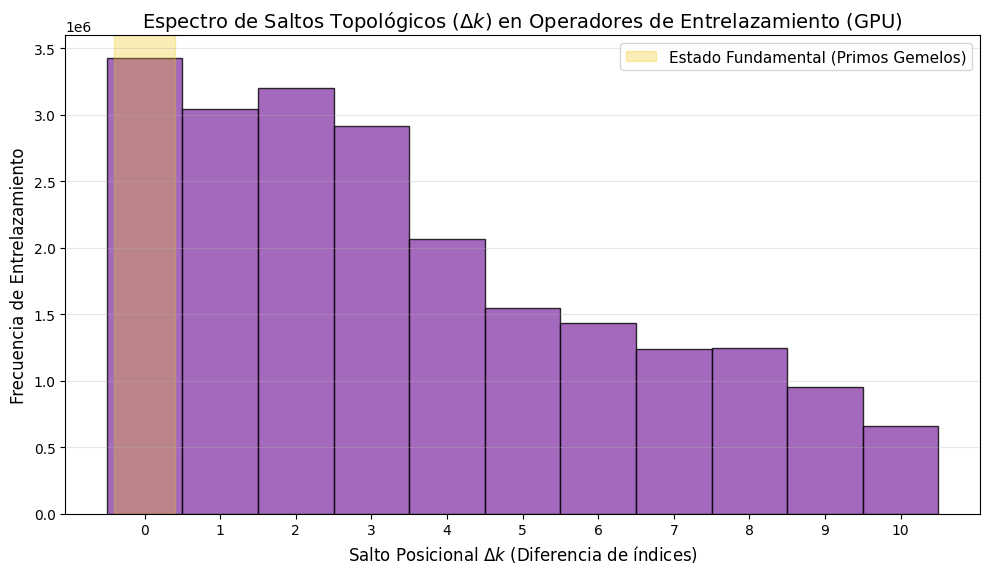

In [7]:
import subprocess
import matplotlib.pyplot as plt
import numpy as np

def analizar_espectro_cuda(k_escala=166666666):
    print(f"Iniciando análisis GPU de saltos topológicos (C5 -> C1) hasta k = {k_escala:,}...")

    # 1. Ejecutar binario CUDA
    proceso = subprocess.run(['./espectro_cuda', str(k_escala)], capture_output=True, text=True)
    salida = proceso.stdout.strip().split('\n')

    datos = {}
    for linea in salida:
        clave, valor = linea.split(':')
        if clave == 'FREQS':
            datos[clave] = [int(x) for x in valor.split(',')]
        elif clave == 'TIME':
            datos[clave] = float(valor)
        else:
            datos[clave] = int(valor)

    conteo_total = datos['TOTAL_C5']
    freqs = datos['FREQS']
    sum_deltak = datos['SUM_DELTA_K']
    conteo_gemelos = freqs[0]

    print("\n" + "="*65)
    print(" RESULTADOS TOPOLÓGICOS EN GPU (ESTADO FUNDAMENTAL)")
    print("="*65)
    print(f"• Total de proyecciones analizadas : {conteo_total:,}")
    print(f"• Estado Fundamental (Gemelos, Δk=0): {conteo_gemelos:,} ({(conteo_gemelos/conteo_total)*100:.2f}%)")
    print(f"• Primer estado excitado   (Δk=1): {freqs[1]:,} ({(freqs[1]/conteo_total)*100:.2f}%)")
    print(f"• Segundo estado excitado  (Δk=2): {freqs[2]:,} ({(freqs[2]/conteo_total)*100:.2f}%)")
    print(f"• Tercer estado excitado   (Δk=3): {freqs[3]:,} ({(freqs[3]/conteo_total)*100:.2f}%)")
    print("-" * 65)
    print(f"• Salto posicional promedio (esperanza) : {sum_deltak/conteo_total:.2f}")
    print(f"• Tiempo de cálculo en GPU             : {datos['TIME']:.3f} s")
    print("="*65)

    # 2. Generar el Histograma de Frecuencias
    plt.figure(figsize=(10, 6))

    # Reconstruir lista de saltos <= 10 a partir de las frecuencias calculadas en GPU
    saltos_filtrados = []
    for dk in range(11):
        saltos_filtrados.extend([dk] * freqs[dk])

    bins = np.arange(-0.5, 11.5, 1)
    plt.hist(saltos_filtrados, bins=bins, color='#8e44ad', edgecolor='black', alpha=0.8)
    plt.axvspan(-0.4, 0.4, color='#f1c40f', alpha=0.3, label='Estado Fundamental (Primos Gemelos)')
    plt.title(r'Espectro de Saltos Topológicos ($\Delta k$) en Operadores de Entrelazamiento (GPU)', fontsize=14)
    plt.xlabel(r'Salto Posicional $\Delta k$ (Diferencia de índices)', fontsize=12)
    plt.ylabel('Frecuencia de Entrelazamiento', fontsize=12)
    plt.xticks(range(11))
    plt.grid(axis='y', alpha=0.3)
    plt.legend(fontsize=11)
    plt.tight_layout()

    # Guardar gráfico
    nombre_archivo = 'espectro_estado_fundamental_cuda.png'
    plt.savefig(nombre_archivo, dpi=300, bbox_inches='tight')
    print(f"\n✅ Gráfico guardado exitosamente en Colab como: '{nombre_archivo}'")
    plt.show()

# Ejecución para N_max ≈ 10^9 (k_max = 166,666,666)
analizar_espectro_cuda(166666666)

In [8]:
%%writefile cramer_cuda.cu
#include <iostream>
#include <vector>
#include <cmath>
#include <chrono>
#include <algorithm>
#include <iomanip>
#include <fstream>
#include <cuda_runtime.h>

// Estructura Compacta de Generadores (Alineada a 16 bytes)
struct alignas(16) PrimoGenerador {
    uint32_t p;
    uint32_t k_p;
    uint32_t kmin_plus;
    uint32_t kmin_minus;
    bool es_c5;
};

// Comprobación de primalidad para poblar la base en CPU
bool es_primo_estricto(uint64_t k, bool check_c5, const std::vector<PrimoGenerador>& base) {
    if (k > 3) {
        uint64_t ultimo_digito = k % 10;
        if (check_c5 && (ultimo_digito == 1 || ultimo_digito == 6)) return false;
        if (!check_c5 && (ultimo_digito == 4 || ultimo_digito == 9)) return false;
    }
    uint64_t n_cand = check_c5 ? (6 * k - 1) : (6 * k + 1);
    for (const auto& gen : base) {
        if (gen.p > n_cand / gen.p) break;
        if (check_c5 == gen.es_c5) {
            if ((k - gen.k_p) % gen.p == 0) return false;
        } else {
            if ((k + gen.k_p) % gen.p == 0) return false;
        }
    }
    return true;
}

uint64_t encontrar_nextkop_host(uint64_t k_inicio, bool c5_objetivo, const std::vector<PrimoGenerador>& base) {
    uint64_t k = k_inicio;
    while (true) {
        if (es_primo_estricto(k, c5_objetivo, base)) return k;
        k++;
    }
}

// Evaluación de primalidad en GPU
__device__ bool es_primo_c5_dev(uint64_t k, const PrimoGenerador* __restrict__ d_base, int base_size) {
    if (k > 3 && (k % 10 == 1 || k % 10 == 6)) return false;
    for (int i = 0; i < base_size; ++i) {
        PrimoGenerador gen = d_base[i];
        if (k < gen.kmin_minus) break;
        if (gen.es_c5) {
            if ((k - gen.k_p) % gen.p == 0) return false;
        } else {
            if ((k + gen.k_p) % gen.p == 0) return false;
        }
    }
    return true;
}

__device__ bool es_primo_c1_dev(uint64_t k, const PrimoGenerador* __restrict__ d_base, int base_size) {
    if (k > 3 && (k % 10 == 4 || k % 10 == 9)) return false;
    for (int i = 0; i < base_size; ++i) {
        PrimoGenerador gen = d_base[i];
        if (k < gen.kmin_plus) break;
        if (!gen.es_c5) {
            if ((k - gen.k_p) % gen.p == 0) return false;
        } else {
            if ((k + gen.k_p) % gen.p == 0) return false;
        }
    }
    return true;
}

// Kernel para rastrear todos los saltos Δk
__global__ void cramer_kernel(uint64_t k_inicio, uint64_t k_max, const PrimoGenerador* __restrict__ d_base, int base_size, uint32_t* d_kps, uint32_t* d_deltas, unsigned long long* d_count) {
    uint64_t idx = blockIdx.x * blockDim.x + threadIdx.x;
    uint64_t k = k_inicio + idx;

    if (k > k_max) return;

    if (es_primo_c5_dev(k, d_base, base_size)) {
        uint64_t kc = k;
        while (kc <= k_max + 2000) {
            if (es_primo_c1_dev(kc, d_base, base_size)) {
                uint32_t delta_k = static_cast<uint32_t>(kc - k);
                unsigned long long pos = atomicAdd(d_count, 1ULL);
                d_kps[pos] = static_cast<uint32_t>(k);
                d_deltas[pos] = delta_k;
                break;
            }
            kc++;
        }
    }
}

int main(int argc, char** argv) {
    uint64_t k_max = 166666666; // Por defecto N ~ 10^9
    if (argc > 1) {
        k_max = std::stoull(argv[1]);
    }

    uint64_t n_max = 6 * k_max + 1;
    uint64_t limite_base = static_cast<uint64_t>(std::sqrt(n_max));
    uint64_t k_lim_base = (limite_base / 6) + 1;

    std::vector<PrimoGenerador> base;
    base.reserve(4000);

    // 1. POBLAR BASE EN CPU
    for (uint64_t k = 1; k <= k_lim_base; ++k) {
        if (es_primo_estricto(k, true, base)) {
            uint64_t p_real = 6 * k - 1;
            if (p_real <= limite_base) {
                uint64_t k_q = encontrar_nextkop_host(k, false, base);
                base.push_back({static_cast<uint32_t>(p_real), static_cast<uint32_t>(k),
                                static_cast<uint32_t>(p_real * k - k), static_cast<uint32_t>(p_real * k_q + k), true});
            }
        }
        if (es_primo_estricto(k, false, base)) {
            uint64_t p_real = 6 * k + 1;
            if (p_real <= limite_base) {
                uint64_t k_q = encontrar_nextkop_host(k, true, base);
                base.push_back({static_cast<uint32_t>(p_real), static_cast<uint32_t>(k),
                                static_cast<uint32_t>(p_real * k + k), static_cast<uint32_t>(p_real * k_q - k), false});
            }
        }
    }

    // 2. RESERVA DE MEMORIA EN GPU
    size_t capacidad_c5 = k_max / 3 + 10000;
    uint32_t *d_kps, *d_deltas;
    unsigned long long *d_count;

    cudaMalloc(&d_kps, capacidad_c5 * sizeof(uint32_t));
    cudaMalloc(&d_deltas, capacidad_c5 * sizeof(uint32_t));
    cudaMalloc(&d_count, sizeof(unsigned long long));
    cudaMemset(d_count, 0, sizeof(unsigned long long));

    int base_size = base.size();
    PrimoGenerador* d_base;
    cudaMalloc(&d_base, base_size * sizeof(PrimoGenerador));
    cudaMemcpy(d_base, base.data(), base_size * sizeof(PrimoGenerador), cudaMemcpyHostToDevice);

    int blockSize = 256;
    int numBlocks = (k_max + blockSize - 1) / blockSize;

    auto start_time = std::chrono::high_resolution_clock::now();
    cramer_kernel<<<numBlocks, blockSize>>>(1, k_max, d_base, base_size, d_kps, d_deltas, d_count);
    cudaDeviceSynchronize();
    auto end_time = std::chrono::high_resolution_clock::now();

    unsigned long long total_elementos;
    cudaMemcpy(&total_elementos, d_count, sizeof(unsigned long long), cudaMemcpyDeviceToHost);

    std::vector<uint32_t> h_kps(total_elementos);
    std::vector<uint32_t> h_deltas(total_elementos);

    cudaMemcpy(h_kps.data(), d_kps, total_elementos * sizeof(uint32_t), cudaMemcpyDeviceToHost);
    cudaMemcpy(h_deltas.data(), d_deltas, total_elementos * sizeof(uint32_t), cudaMemcpyDeviceToHost);

    // 3. ORDENAR PARES POR ÍNDICE k_p
    std::vector<std::pair<uint32_t, uint32_t>> pares(total_elementos);
    for (size_t i = 0; i < total_elementos; ++i) {
        pares[i] = {h_kps[i], h_deltas[i]};
    }
    std::sort(pares.begin(), pares.end());

    for (size_t i = 0; i < total_elementos; ++i) {
        h_kps[i] = pares[i].first;
        h_deltas[i] = pares[i].second;
    }

    // 4. ANÁLISIS DE REGISTROS Y COTA DE CRAMÉR
    std::cout << "================================================================================\n";
    std::cout << " REGISTRO DE SALTOS MÁXIMOS (ESCALONES TOPOLÓGICOS vs CRAMÉR)\n";
    std::cout << "================================================================================\n";
    std::cout << std::setw(10) << "Índice kp" << " | "
              << std::setw(10) << "Primo C5" << " | "
              << std::setw(10) << "Primo C1" << " | "
              << std::setw(10) << "Salto Δk" << " | "
              << std::setw(12) << "Brecha Real" << " | "
              << std::setw(22) << "Cota Cramér (ln p)^2" << "\n";
    std::cout << "--------------------------------------------------------------------------------\n";

    int32_t max_actual = -1;
    uint64_t locales = 0;
    uint64_t extremos = 0;

    for (size_t i = 0; i < total_elementos; ++i) {
        uint32_t kp = h_kps[i];
        uint32_t dk = h_deltas[i];

        if (dk <= 3) locales++;
        if (dk > 20) extremos++;

        if (static_cast<int32_t>(dk) > max_actual) {
            max_actual = dk;
            uint64_t p5 = 6ULL * kp - 1;
            uint64_t p1 = 6ULL * (kp + dk) + 1;
            uint64_t brecha = p1 - p5;
            double cota_cramer = (p5 > 1) ? std::pow(std::log(p5), 2.0) : 0.0;
            std::string marca = (brecha > cota_cramer) ? " ⚠️" : "";

            std::cout << std::setw(10) << kp << " | "
                      << std::setw(10) << p5 << " | "
                      << std::setw(10) << p1 << " | "
                      << std::setw(10) << dk << " | "
                      << std::setw(12) << brecha << " | "
                      << std::setw(22) << std::fixed << std::setprecision(2) << cota_cramer << marca << "\n";
        }
    }
    std::cout << "================================================================================\n";

    std::chrono::duration<double> elapsed = end_time - start_time;
    std::cout << "\nResumen Estadístico para k_max = " << k_max << "\n";
    std::cout << "• Proyecciones totales evaluadas : " << total_elementos << "\n";
    std::cout << "• Saltos locales (Δk <= 3)        : " << locales << " (" << std::fixed << std::setprecision(2) << (locales * 100.0 / total_elementos) << "%)\n";
    std::cout << "• Saltos extremos (Δk > 20)      : " << extremos << " (" << std::setprecision(4) << (extremos * 100.0 / total_elementos) << "%)\n";
    std::cout << "• Tiempo de ejecución GPU        : " << std::setprecision(3) << elapsed.count() << " segundos\n";

    // 5. EXPORTAR DATOS BINARIOS PARA PYTHON
    std::ofstream bin_out("cramer_data.bin", std::ios::binary);
    uint64_t num_elems = total_elementos;
    bin_out.write(reinterpret_cast<const char*>(&num_elems), sizeof(uint64_t));
    bin_out.write(reinterpret_cast<const char*>(h_kps.data()), num_elems * sizeof(uint32_t));
    bin_out.write(reinterpret_cast<const char*>(h_deltas.data()), num_elems * sizeof(uint32_t));
    bin_out.close();

    cudaFree(d_base);
    cudaFree(d_kps);
    cudaFree(d_deltas);
    cudaFree(d_count);
    return 0;
}

Writing cramer_cuda.cu


In [9]:
!nvcc -O3 -arch=sm_75 -use_fast_math cramer_cuda.cu -o cramer_cuda

Rastreando la evolución topológica masiva en GPU hasta k = 166,666,666...

 REGISTRO DE SALTOS MÁXIMOS (ESCALONES TOPOLÓGICOS vs CRAMÉR)
Índice kp |   Primo C5 |   Primo C1 |  Salto Δk |  Brecha Real |  Cota Cramér (ln p)^2
--------------------------------------------------------------------------------
         1 |          5 |          7 |          0 |            2 |                   2.59
         4 |         23 |         31 |          1 |            8 |                   9.83
         8 |         47 |         61 |          2 |           14 |                  14.82
        42 |        251 |        271 |          3 |           20 |                  30.53
       157 |        941 |        967 |          4 |           26 |                  46.88
       249 |       1493 |       1531 |          6 |           38 |                  53.41
       315 |       1889 |       1933 |          7 |           44 |                  56.91
       729 |       4373 |       4423 |          8 |           50 

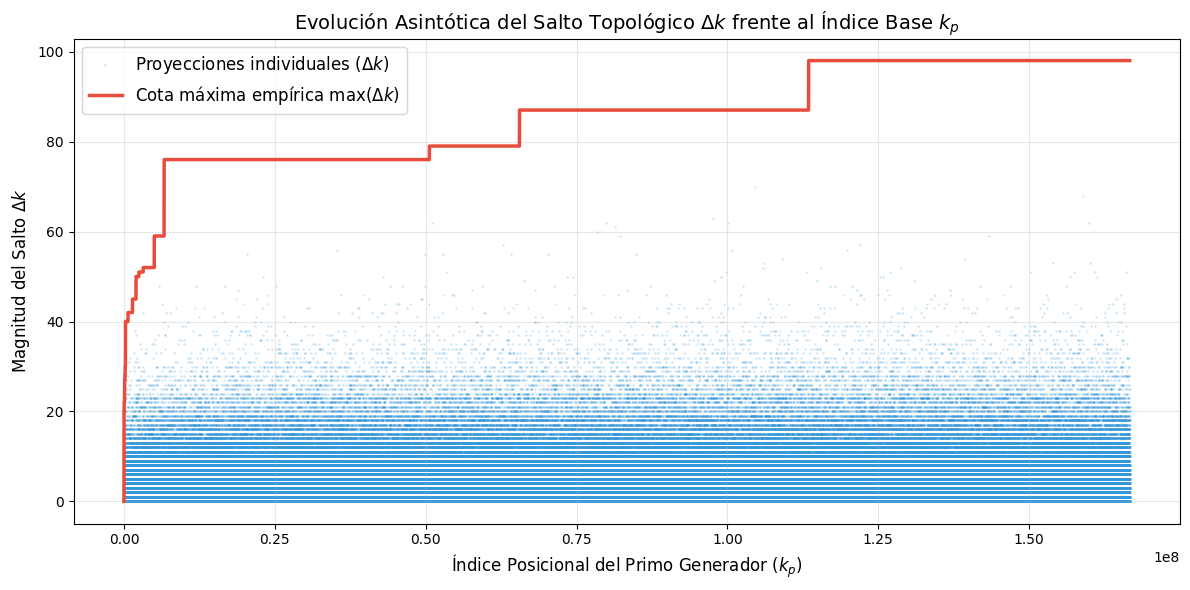

In [10]:
import subprocess
import numpy as np
import matplotlib.pyplot as plt

def ejecutar_y_graficar_cramer(k_escala_masiva=166666666):
    print(f"Rastreando la evolución topológica masiva en GPU hasta k = {k_escala_masiva:,}...\n")

    # 1. Ejecutar binario CUDA streaming salida en tiempo real
    proceso = subprocess.Popen(
        ['./cramer_cuda', str(k_escala_masiva)],
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
        bufsize=1
    )

    for linea in iter(proceso.stdout.readline, ''):
        print(linea, end='')

    proceso.stdout.close()
    proceso.wait()

    # 2. Cargar datos binarios de alta velocidad
    with open('cramer_data.bin', 'rb') as f:
        total_elems = np.fromfile(f, dtype=np.uint64, count=1)[0]
        kps = np.fromfile(f, dtype=np.uint32, count=total_elems)
        saltos = np.fromfile(f, dtype=np.uint32, count=total_elems)

    # 3. Calcular envolvente de máximos acumulados
    maximos_acumulados = np.maximum.accumulate(saltos)

    # 4. Submuestreo inteligente ajustado para 25 millones de puntos (N=10^9)
    # Aumentamos de 100k a 500k para mantener la densidad visual sin saturar la RAM
    limite_puntos = 500000
    if len(kps) > limite_puntos:
        indices_sub = np.linspace(0, len(kps) - 1, limite_puntos, dtype=int)
        kps_plot = kps[indices_sub]
        saltos_plot = saltos[indices_sub]
    else:
        kps_plot = kps
        saltos_plot = saltos

    # 5. Generar gráfico estilo manuscrito
    plt.figure(figsize=(12, 6))
    plt.scatter(kps_plot, saltos_plot, s=1, alpha=0.15, color='#3498db', label=r'Proyecciones individuales ($\Delta k$)')
    plt.plot(kps, maximos_acumulados, color='#e74c3c', linewidth=2.5, label=r'Cota máxima empírica $\max(\Delta k)$')

    plt.title(r'Evolución Asintótica del Salto Topológico $\Delta k$ frente al Índice Base $k_p$', fontsize=14)
    plt.xlabel(r'Índice Posicional del Primo Generador ($k_p$)', fontsize=12)
    plt.ylabel(r'Magnitud del Salto $\Delta k$', fontsize=12)
    plt.grid(alpha=0.3)
    plt.legend(fontsize=12, loc='upper left')
    plt.tight_layout()

    nombre_archivo = 'evolucion_asintotica_cramer.png'
    plt.savefig(nombre_archivo, dpi=300, bbox_inches='tight')
    print(f"\n✅ Gráfico guardado exitosamente en Colab como: '{nombre_archivo}'")
    plt.show()

# Ejecución para escala masiva N ≈ 10^9 (k_max = 166,666,666)
ejecutar_y_graficar_cramer(166666666)

In [11]:
%%writefile goe_cuda.cu
#include <iostream>
#include <vector>
#include <cmath>
#include <chrono>
#include <fstream>
#include <cuda_runtime.h>

// Evaluador clásico para extraer la base
bool es_primo_host(uint64_t k) {
    if (k <= 3) return k > 1;
    if (k % 2 == 0 || k % 3 == 0) return false;
    for (uint64_t i = 5; i * i <= k; i += 6) {
        if (k % i == 0 || k % (i + 2) == 0) return false;
    }
    return true;
}

// KERNEL: Construcción directa del Operador de Densidad M^T M
__global__ void build_mtm_kernel(uint64_t k_max, const uint32_t* __restrict__ d_primos, int num_primos, unsigned long long* d_MTM) {
    uint64_t k = blockIdx.x * blockDim.x + threadIdx.x + 1;
    if (k > k_max) return;

    // Un número <= 10^10 tiene como máximo ~10 factores primos distintos.
    // Asignamos 32 por seguridad absoluta.
    int local_factors[32];
    int num_factors = 0;

    uint64_t c5 = 6ULL * k - 1;
    uint64_t c1 = 6ULL * k + 1;

    for (int j = 0; j < num_primos; ++j) {
        uint64_t p = d_primos[j];
        uint64_t p2 = p * p;
        if (p2 > c1) break; // Termodinámica: si p^2 > estado, no hay aniquilación posible

        bool divides = false;
        if (c5 >= p2 && c5 % p == 0) divides = true;
        if (!divides && c1 >= p2 && c1 % p == 0) divides = true;

        if (divides) {
            local_factors[num_factors++] = j;
            if (num_factors >= 32) break;
        }
    }

    // Interferencia Cuántica: Acumulación de co-ocurrencias (Producto Exterior)
    for (int a = 0; a < num_factors; ++a) {
        for (int b = 0; b < num_factors; ++b) {
            int i = local_factors[a];
            int j = local_factors[b];
            atomicAdd(&d_MTM[i * num_primos + j], 1ULL);
        }
    }
}

int main(int argc, char** argv) {
    uint64_t k_max = 1000000000ULL; // Ajuste para 10^9 posiciones
    if (argc > 1) k_max = std::stoull(argv[1]);

    uint64_t n_max = 6ULL * k_max + 1;
    uint64_t limite_base = static_cast<uint64_t>(std::sqrt(n_max));

    std::vector<uint32_t> primos_base;
    for (uint64_t p = 5; p <= limite_base; p++) {
        if (es_primo_host(p)) primos_base.push_back(static_cast<uint32_t>(p));
    }

    int num_primos = primos_base.size();

    uint32_t* d_primos;
    cudaMalloc(&d_primos, num_primos * sizeof(uint32_t));
    cudaMemcpy(d_primos, primos_base.data(), num_primos * sizeof(uint32_t), cudaMemcpyHostToDevice);

    unsigned long long* d_MTM;
    size_t mtm_bytes = static_cast<size_t>(num_primos) * num_primos * sizeof(unsigned long long);
    cudaMalloc(&d_MTM, mtm_bytes);
    cudaMemset(d_MTM, 0, mtm_bytes);

    int blockSize = 256;
    int numBlocks = (k_max + blockSize - 1) / blockSize;

    auto start = std::chrono::high_resolution_clock::now();
    build_mtm_kernel<<<numBlocks, blockSize>>>(k_max, d_primos, num_primos, d_MTM);
    cudaDeviceSynchronize();
    auto end = std::chrono::high_resolution_clock::now();

    std::vector<unsigned long long> h_MTM(num_primos * num_primos);
    cudaMemcpy(h_MTM.data(), d_MTM, mtm_bytes, cudaMemcpyDeviceToHost);

    // Exportación ultrarrápida del hamiltoniano cuántico
    std::ofstream bin_out("mtm_matrix.bin", std::ios::binary);
    uint32_t np_out = num_primos;
    bin_out.write(reinterpret_cast<const char*>(&np_out), sizeof(uint32_t));
    bin_out.write(reinterpret_cast<const char*>(h_MTM.data()), mtm_bytes);
    bin_out.close();

    std::chrono::duration<double> elapsed = end - start;
    std::cout << "OK:" << num_primos << ":" << elapsed.count() << "\n";

    cudaFree(d_primos);
    cudaFree(d_MTM);
    return 0;
}

Writing goe_cuda.cu


In [12]:
!nvcc -O3 -arch=sm_75 -use_fast_math goe_cuda.cu -o goe_cuda

 EXPERIMENTO 6: ESPECTROSCOPÍA CUÁNTICA MASIVA (GPU) (k_max = 1,000,000,000)
Generando Operador de Interferencia M^T M en GPU (100 millones de estados)...
✅ Matriz cuántica colapsada en 154.948 s. Estados base detectados: 7,606
Diagonalizando matriz densa de 7606x7606 vía SciPy...
-------------------------------------------------------------------------------------
 1. TEOREMA DEL RANGO Y COLAPSO DIMENSIONAL
-------------------------------------------------------------------------------------
• Dimensión Total del Espacio de Hilbert (k_max) : 1,000,000,000
• Estados de Energía Excitados (Autovalores)     : 7,606
• Dimensión del Espacio Nulo (Primos, λ = 0)     : 999,992,394 (99.9992%)

-------------------------------------------------------------------------------------
 2. CAOS ESPECTRAL Y ANÁLISIS DE REPULSIÓN DE NIVELES (ESTADÍSTICA r)
-------------------------------------------------------------------------------------
• Niveles de Energía Distintos Evaluados     : 7,606
• Ratio de

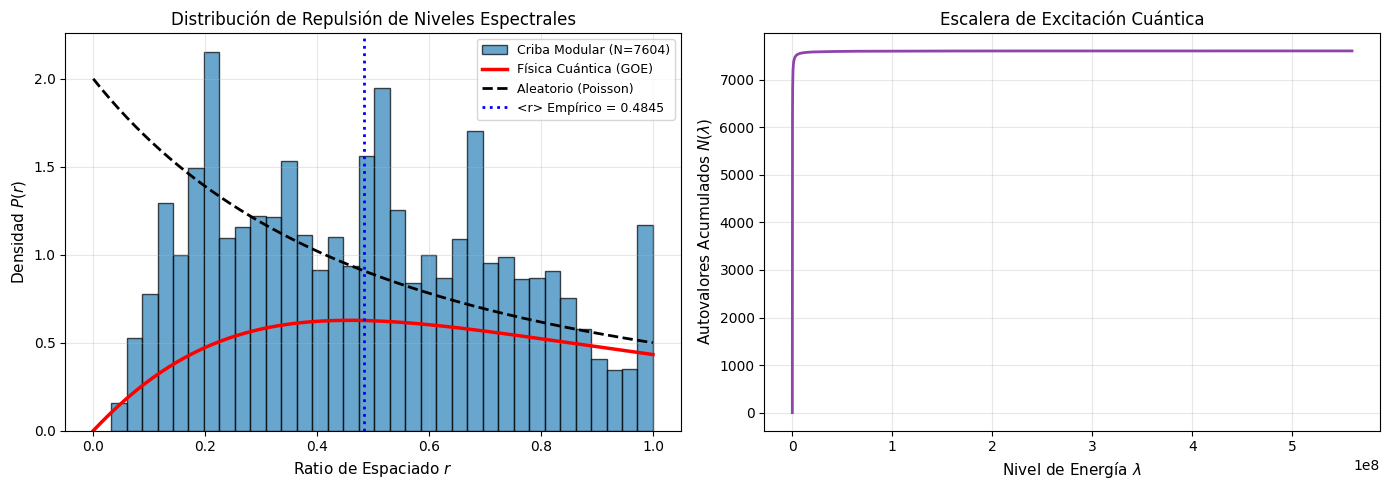

In [13]:
import subprocess
import numpy as np
from scipy.linalg import eigvalsh
import matplotlib.pyplot as plt

def analisis_espectral_cuda(k_escala_masiva=1000000000):
    print("=" * 85)
    print(f" EXPERIMENTO 6: ESPECTROSCOPÍA CUÁNTICA MASIVA (GPU) (k_max = {k_escala_masiva:,})")
    print("=" * 85)

    # 1. Ejecutar Kernel y construir el Hamiltoniano
    print("Generando Operador de Interferencia M^T M en GPU (1000 millones de estados)...")
    proceso = subprocess.run(['./goe_cuda', str(k_escala_masiva)], capture_output=True, text=True)
    salida = proceso.stdout.strip().split(':')

    if salida[0] != "OK":
        print("Error en ejecución CUDA:", proceso.stderr)
        return

    num_primos = int(salida[1])
    tiempo_gpu = float(salida[2])

    print(f"✅ Matriz cuántica colapsada en {tiempo_gpu:.3f} s. Estados base detectados: {num_primos:,}")

    # 2. Cargar y Diagonalizar (Resolución de Valores Propios)
    print(f"Diagonalizando matriz densa de {num_primos}x{num_primos} vía SciPy...")
    with open('mtm_matrix.bin', 'rb') as f:
        np_out = np.fromfile(f, dtype=np.uint32, count=1)[0]
        M_T_M_flat = np.fromfile(f, dtype=np.uint64, count=np_out * np_out)

    M_T_M = M_T_M_flat.reshape((num_primos, num_primos)).astype(np.float64)
    autovalores = eigvalsh(M_T_M)

    # Separar excitados
    excitados_brutos = np.sort(autovalores[autovalores > 1e-6])
    dimension_nula = k_escala_masiva - len(excitados_brutos)

    print("-" * 85)
    print(" 1. TEOREMA DEL RANGO Y COLAPSO DIMENSIONAL")
    print("-" * 85)
    print(f"• Dimensión Total del Espacio de Hilbert (k_max) : {k_escala_masiva:,}")
    print(f"• Estados de Energía Excitados (Autovalores)     : {len(excitados_brutos):,}")
    print(f"• Dimensión del Espacio Nulo (Primos, λ = 0)     : {dimension_nula:,} ({(dimension_nula/k_escala_masiva)*100:.4f}%)")

    # 3. Estadística de Repulsión r_i (GOE vs Poisson)
    print("\n" + "-" * 85)
    print(" 2. CAOS ESPECTRAL Y ANÁLISIS DE REPULSIÓN DE NIVELES (ESTADÍSTICA r)")
    print("-" * 85)

    niveles_distintos = np.unique(np.round(excitados_brutos, decimals=3))
    espaciados = np.diff(niveles_distintos)
    espaciados_limpios = espaciados[espaciados > 1e-4]

    r_i = np.minimum(espaciados_limpios[:-1], espaciados_limpios[1:]) / np.maximum(espaciados_limpios[:-1], espaciados_limpios[1:])
    r_promedio = np.mean(r_i)

    print(f"• Niveles de Energía Distintos Evaluados     : {len(niveles_distintos):,}")
    print(f"• Ratio de Espaciado Promedio <r>            : {r_promedio:.4f}")
    print("-" * 85)
    print("• Comparativas de Referencia Universales:")
    print(f"  - GOE (Ensamble Ortogonal Gaussiano) : ~0.5307")
    print(f"  - Poisson (Sistemas Integrables)     : ~0.3863")

    # 4. Gráficos GOE
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    r_vals = np.linspace(0, 1, 200)
    p_goe = (27/8) * (r_vals + r_vals**2) / ((1 + r_vals + r_vals**2)**(2.5))
    p_poisson = 2 / ((1 + r_vals)**2)

    ax[0].hist(r_i, bins=35, density=True, alpha=0.7, color='#2980b9', edgecolor='black', label=f'Criba Modular (N={len(r_i)})')
    ax[0].plot(r_vals, p_goe, 'r-', linewidth=2.5, label='Física Cuántica (GOE)')
    ax[0].plot(r_vals, p_poisson, 'k--', linewidth=2.0, label='Aleatorio (Poisson)')
    ax[0].axvline(r_promedio, color='blue', linestyle=':', linewidth=2, label=f'<r> Empírico = {r_promedio:.4f}')
    ax[0].set_title(r'Distribución de Repulsión de Niveles Espectrales', fontsize=12)
    ax[0].set_xlabel(r'Ratio de Espaciado $r$', fontsize=11)
    ax[0].set_ylabel(r'Densidad $P(r)$', fontsize=11)
    ax[0].legend(fontsize=9)
    ax[0].grid(alpha=0.3)

    ax[1].plot(niveles_distintos, np.arange(1, len(niveles_distintos) + 1), color='#8e44ad', linewidth=2)
    ax[1].set_title(r'Escalera de Excitación Cuántica', fontsize=12)
    ax[1].set_xlabel(r'Nivel de Energía $\lambda$', fontsize=11)
    ax[1].set_ylabel(r'Autovalores Acumulados $N(\lambda)$', fontsize=11)
    ax[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('espectroscopia_goe_escalera_cuda.png', dpi=300, bbox_inches='tight')
    print("\n✅ Gráficos guardados exitosamente como: 'espectroscopia_goe_escalera_cuda.png'")
    plt.show()

# Ejecución a escala colosal (1000 millones)
analisis_espectral_cuda(1000000000)